# 02 · Data Cleaning

**Input :** raw 15-minute FIETSERS CSV files for 2023–2025 (`data/raw/cycling/`)  
**Output:** `data/processed/panel_15min_clean.parquet` — one row per (site × 15-min slot), direction-aggregated, outliers removed, gaps flagged

Sections:
1. Basic data inspection
2. Direction handling (IN + OUT → total flow)
3. Negative / zero / outlier analysis
4. Missing-timestamp analysis
5. Missing-value strategy + forward-fill
6. Save cleaned panel

## 0. Imports & Config

In [1]:
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
%matplotlib inline
plt.rcParams["figure.dpi"] = 120

ROOT      = Path().resolve().parent
RAW_CYC   = ROOT / "data" / "raw" / "cycling"
PROCESSED = ROOT / "data" / "processed"
FIGS      = ROOT / "outputs" / "figures"
PROCESSED.mkdir(parents=True, exist_ok=True)
FIGS.mkdir(parents=True, exist_ok=True)

STUDY_YEARS  = {2023, 2024, 2025}
SPINE_START  = pd.Timestamp("2023-01-01 00:00")
SPINE_END    = pd.Timestamp("2025-12-31 23:45")
# 2023 = 365 days, 2024 = 366 days, 2025 = 365 days → 1096 × 96 = 105,216 slots per station
N_SLOTS      = 1096 * 96

MISS_THRESH  = 0.20   # >20% missing → flagged, not imputed
FFILL_LIMIT  = 4      # max consecutive slots to forward-fill (= 1 hour)
OUTLIER_STD  = 4      # flag values > mean + N*std per station

CSV_COLS  = ["site ID", "richting", "type", "van", "tot", "aantal"]
USE_COLS  = ["site ID", "richting", "type", "van", "aantal"]
COL_TYPES = {"site ID": "Int32", "richting": str, "type": str, "aantal": "float32"}
FNAME_RE  = re.compile(r"data-(\d{4})-(\d{2})\.csv$")

print(f"Spine: {SPINE_START} → {SPINE_END}  ({N_SLOTS:,} slots / station)")

Spine: 2023-01-01 00:00:00 → 2025-12-31 23:45:00  (105,216 slots / station)


## 1. Basic Data Inspection

Load all 2023–2025 FIETSERS rows at full 15-minute granularity, keeping the `richting` column for direction analysis in section 2.

In [2]:
chunks = []
for csv in sorted(RAW_CYC.rglob("*.csv")):
    m = FNAME_RE.search(csv.name)
    if not m or int(m.group(1)) not in STUDY_YEARS:
        continue
    df = pd.read_csv(csv, header=None, names=CSV_COLS,
                     usecols=USE_COLS, dtype=COL_TYPES)
    df = df[df["type"] == "FIETSERS"].copy()
    df["van"] = pd.to_datetime(df["van"], format="mixed")
    df.drop(columns="type", inplace=True)
    chunks.append(df)

raw = pd.concat(chunks, ignore_index=True)
print(f"Shape       : {raw.shape}")
print(f"\nDtypes:")
print(raw.dtypes)
print(f"\nMissing values per column:")
print(raw.isnull().sum())
print(f"\nUnique site IDs  : {raw['site ID'].nunique()}")
print(f"Unique richting  : {raw['richting'].unique().tolist()}")
print(f"Date range       : {raw['van'].min()} → {raw['van'].max()}")
raw.head(4)

Shape       : (29165328, 4)

Dtypes:
site ID              Int32
richting            object
van         datetime64[ns]
aantal             float32
dtype: object

Missing values per column:
site ID          0
richting         0
van              0
aantal      402021
dtype: int64

Unique site IDs  : 150
Unique richting  : ['IN', 'OUT']
Date range       : 2023-01-01 00:00:00 → 2025-12-31 23:45:00


,site ID,richting,van,aantal
0,1,IN,2023-01-01 00:00:00,0.0
1,1,IN,2023-01-01 00:15:00,0.0
2,1,IN,2023-01-01 00:30:00,0.0
3,1,IN,2023-01-01 00:45:00,0.0


In [3]:
# ── time-interval distribution ────────────────────────────────────────────────
# compute gap between consecutive timestamps within each (site, direction)
raw_sorted = raw.sort_values(["site ID", "richting", "van"])
raw_sorted["gap_min"] = (
    raw_sorted.groupby(["site ID", "richting"])["van"]
    .diff()
    .dt.total_seconds()
    .div(60)
)

gap_counts = raw_sorted["gap_min"].value_counts().sort_index()
print("Interval distribution (minutes):")
total_gaps = gap_counts.sum()
for gap, cnt in gap_counts.items():
    pct = cnt / total_gaps * 100
    flag = " ← anomaly" if gap not in (15.0,) and cnt > 100 else ""
    if pct > 0.001 or cnt > 50:
        print(f"  {gap:>8.1f} min : {cnt:>10,} ({pct:.3f}%){flag}")

anomalies = raw_sorted[~raw_sorted["gap_min"].isin([15.0, np.nan])]
print(f"\nAnomalous intervals (not 15 min): {len(anomalies):,} rows")
if len(anomalies):
    display(anomalies[["site ID","richting","van","gap_min"]].head(10))

Interval distribution (minutes):
      15.0 min : 29,164,744 (99.999%)
      75.0 min :        274 (0.001%) ← anomaly

Anomalous intervals (not 15 min): 284 rows


,site ID,richting,van,gap_min
1503188,1,IN,2023-03-26 03:00:00,75.0
1506160,1,OUT,2023-03-26 03:00:00,75.0
1509132,2,IN,2023-03-26 03:00:00,75.0
1512104,2,OUT,2023-03-26 03:00:00,75.0
1515076,3,IN,2023-03-26 03:00:00,75.0
1518048,3,OUT,2023-03-26 03:00:00,75.0
1521020,4,IN,2023-03-26 03:00:00,75.0
1523992,4,OUT,2023-03-26 03:00:00,75.0
1526964,5,IN,2023-03-26 03:00:00,75.0
1529936,5,OUT,2023-03-26 03:00:00,75.0


## 2. Direction Handling

AWV files contain separate IN and OUT rows per station per interval.  
We need one row per `(site ID, timestamp)` = total bidirectional flow.

In [4]:
# ── which stations have which directions? ─────────────────────────────────────
dir_summary = (
    raw.groupby("site ID")["richting"]
    .apply(lambda x: frozenset(x.unique()))
    .reset_index(name="directions")
)
dir_counts = dir_summary["directions"].value_counts()
print("Direction combinations across stations:")
for combo, cnt in dir_counts.items():
    print(f"  {set(combo)} : {cnt} stations")

in_out_combined = dir_summary[dir_summary["directions"] == frozenset({"IN/OUT"})]
both_sep        = dir_summary[dir_summary["directions"] == frozenset({"IN","OUT"})]
in_only         = dir_summary[dir_summary["directions"] == frozenset({"IN"})]
out_only        = dir_summary[dir_summary["directions"] == frozenset({"OUT"})]

print(f"\n  IN only          : {len(in_only)} stations")
print(f"  OUT only         : {len(out_only)} stations")
print(f"  Both IN & OUT    : {len(both_sep)} stations")
print(f"  IN/OUT combined  : {len(in_out_combined)} stations")

Direction combinations across stations:
  {'OUT', 'IN'} : 150 stations

  IN only          : 0 stations
  OUT only         : 0 stations
  Both IN & OUT    : 150 stations
  IN/OUT combined  : 0 stations


In [5]:
rows_before = len(raw)

# sum IN + OUT (and any IN/OUT) per (site ID, timestamp)
df = (
    raw.groupby(["site ID", "van"], as_index=False)["aantal"]
    .sum(min_count=1)    # NaN if all inputs are NaN
)

rows_after = len(df)
print(f"Rows before direction aggregation : {rows_before:,}")
print(f"Rows after  direction aggregation : {rows_after:,}")
print(f"Reduction factor                  : {rows_before/rows_after:.2f}×")
print(f"Unique sites                      : {df['site ID'].nunique()}")
df.head(4)

Rows before direction aggregation : 29,165,328
Rows after  direction aggregation : 14,582,664
Reduction factor                  : 2.00×
Unique sites                      : 150


,site ID,van,aantal
0,1,2023-01-01 00:00:00,0.0
1,1,2023-01-01 00:15:00,0.0
2,1,2023-01-01 00:30:00,0.0
3,1,2023-01-01 00:45:00,0.0


In [6]:
# ── Issue 1 check: verify min_count=1 correctly handles partial NaN ──────
# Aggregation line in the cell above:
#   raw.groupby(["site ID", "van"])["aantal"].sum(min_count=1)
#
# min_count=1: result is NaN only when ALL inputs are NaN
#   IN=5, OUT=NaN  →  5    (correct: partial NaN preserved)
#   IN=NaN, OUT=NaN →  NaN (correct: both NaN stays NaN)

# Fast vectorised check -- pivot NaN mask then compare counts
nan_mask = raw[["site ID", "van", "aantal"]].copy()
nan_mask["is_nan"] = nan_mask["aantal"].isna()

slot_agg = (
    nan_mask.groupby(["site ID", "van"])["is_nan"]
    .agg(n_nan="sum", n_rows="count")
    .reset_index()
)
mixed = slot_agg[(slot_agg["n_nan"] > 0) & (slot_agg["n_nan"] < slot_agg["n_rows"])]

print(f"NaN rows in raw before aggregation           : {raw['aantal'].isna().sum():,}")
print(f"NaN rows in df  after  aggregation           : {df['aantal'].isna().sum():,}")
print(f"Slots with mixed NaN/non-NaN (should survive): {len(mixed):,}")

# spot-check: all mixed slots should be non-NaN in df
sample = mixed.head(5000)
merged = sample[["site ID", "van"]].merge(df, on=["site ID", "van"])
still_nan = merged["aantal"].isna().sum()
print(f"Of first 5000 mixed slots, incorrectly NaN in df: {still_nan}  (should be 0)")

if still_nan == 0:
    print()
    print("Issue 1: min_count=1 already present and working correctly — no fix needed.")
else:
    print()
    print("Issue 1: FIX REQUIRED — partial-NaN slots incorrectly became NaN.")


NaN rows in raw before aggregation           : 402,021
NaN rows in df  after  aggregation           : 200,857
Slots with mixed NaN/non-NaN (should survive): 307
Of first 5000 mixed slots, incorrectly NaN in df: 0  (should be 0)

Issue 1: min_count=1 already present and working correctly — no fix needed.


## 3. Negative and Zero Value Analysis

In [7]:
# ── negatives ─────────────────────────────────────────────────────────────────
n_neg = (df["aantal"] < 0).sum()
print(f"Rows with aantal < 0 : {n_neg:,}")
if n_neg:
    display(df[df["aantal"] < 0].head(5))
df.loc[df["aantal"] < 0, "aantal"] = np.nan
print(f"  → set to NaN")

# ── zeros ─────────────────────────────────────────────────────────────────────
n_zero = (df["aantal"] == 0).sum()
n_total = df["aantal"].notna().sum()
print(f"\nRows with aantal == 0 : {n_zero:,}  ({n_zero/n_total*100:.1f}% of non-NaN)")
print("  → zeros kept as-is (legitimate low-traffic periods)")

Rows with aantal < 0 : 0
  → set to NaN

Rows with aantal == 0 : 4,927,301  (34.3% of non-NaN)
  → zeros kept as-is (legitimate low-traffic periods)


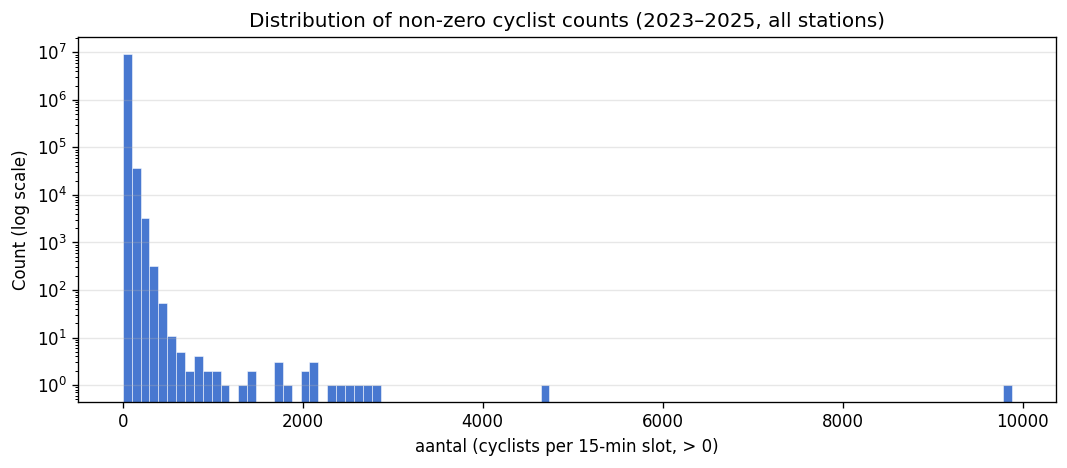

Non-zero count statistics:
count    9454506.0
mean           8.3
std           15.1
min            1.0
50%            4.0
75%            9.0
95%           30.0
99%           71.0
max         9876.0
Name: aantal, dtype: float64


In [8]:
# ── distribution of non-zero values ──────────────────────────────────────────
nonzero = df.loc[df["aantal"] > 0, "aantal"].dropna()

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(nonzero, bins=100, color="#4878d0", edgecolor="white", linewidth=0.3)
ax.set_yscale("log")
ax.set_xlabel("aantal (cyclists per 15-min slot, > 0)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Distribution of non-zero cyclist counts (2023–2025, all stations)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig04_count_distribution.png", dpi=150)
plt.show()

print(f"Non-zero count statistics:")
print(nonzero.describe(percentiles=[.50,.75,.95,.99]).round(1))

In [9]:
# ── per-station outlier detection (> mean + 4σ) ───────────────────────────────
station_stats = (
    df.groupby("site ID")["aantal"]
    .agg(mu="mean", sigma="std")
    .reset_index()
)
station_stats["threshold"] = station_stats["mu"] + OUTLIER_STD * station_stats["sigma"]

df = df.merge(station_stats[["site ID","threshold"]], on="site ID", how="left")
outlier_mask = df["aantal"] > df["threshold"]
n_outliers   = outlier_mask.sum()

outlier_summary = (
    df[outlier_mask]
    .groupby("site ID")["aantal"]
    .agg(n_flagged="count", max_value="max")
    .reset_index()
    .sort_values("n_flagged", ascending=False)
)
print(f"Total outlier rows flagged (>μ+{OUTLIER_STD}σ): {n_outliers:,}")
if len(outlier_summary):
    print(f"Stations with at least one outlier: {len(outlier_summary)}")
    display(outlier_summary.head(10))

df.loc[outlier_mask, "aantal"] = np.nan
df.drop(columns="threshold", inplace=True)
print(f"\nOutliers set to NaN. Total NaN in aantal: {df['aantal'].isna().sum():,}")

Total outlier rows flagged (>μ+4σ): 121,469
Stations with at least one outlier: 149


,site ID,n_flagged,max_value
86,87,1622,261.0
5,6,1486,87.0
75,76,1411,113.0
98,99,1365,82.0
24,25,1357,249.0
74,75,1338,109.0
47,48,1328,288.0
124,125,1311,374.0
61,62,1271,142.0
50,51,1265,327.0



Outliers set to NaN. Total NaN in aantal: 322,326


## 4. Missing Timestamp Analysis

Build a complete 15-minute spine (105,216 slots per station) and left-join the cleaned data to expose all implicit gaps.

In [10]:
all_slots    = pd.date_range(SPINE_START, SPINE_END, freq="15min")
all_stations = df["site ID"].unique()
n_stations   = len(all_stations)

print(f"Spine: {n_stations} stations × {len(all_slots):,} slots = {n_stations*len(all_slots):,} rows")
assert len(all_slots) == N_SLOTS, f"Expected {N_SLOTS} slots, got {len(all_slots)}"

spine = pd.DataFrame(
    [(sid, ts) for sid in all_stations for ts in all_slots],
    columns=["site ID", "van"],
)

df_full = spine.merge(df, on=["site ID", "van"], how="left")
print(f"Full panel rows : {len(df_full):,}")
print(f"Implicit + explicit NaN in aantal: {df_full['aantal'].isna().sum():,}")

Spine: 150 stations × 105,216 slots = 15,782,400 rows
Full panel rows : 15,782,400
Implicit + explicit NaN in aantal: 1,522,062


Missing-data distribution across stations:
    0%       :    0 stations
  (  0–  5%] :  123 stations
  (  5– 20%] :   10 stations
  ( 20– 50%] :    5 stations
  ( 50–100%] :   12 stations

Stations > 20% missing → will be flagged: 17


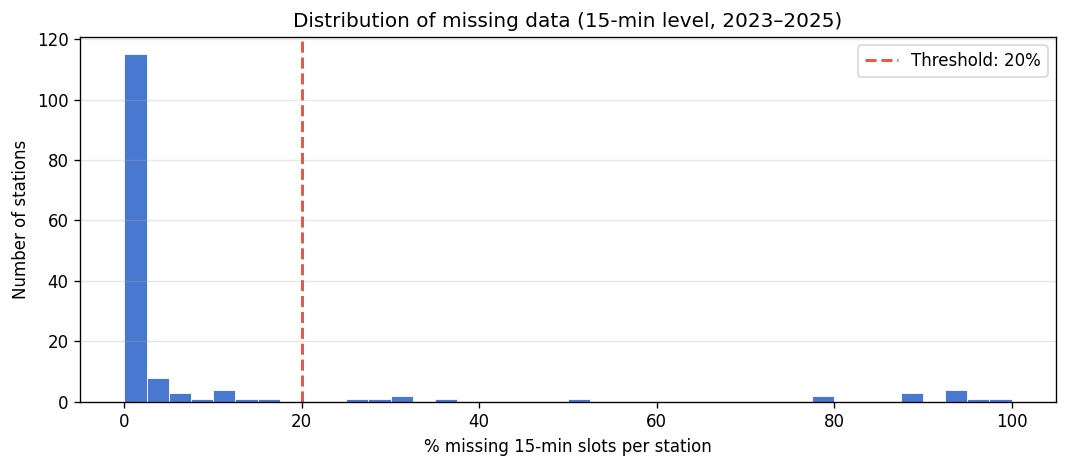


Stations with >20% missing:


,site ID,n_expected,n_actual,n_missing,pct_missing
0,144,105216,0,105216,100.000000
1,142,105216,3867,101349,96.324703
2,152,105216,5958,99258,94.337363
3,151,105216,7185,98031,93.171191
4,150,105216,7335,97881,93.028627
5,123,105216,7495,97721,92.876559
6,149,105216,12058,93158,88.539766
7,148,105216,12509,92707,88.111124
8,147,105216,12624,92592,88.001825
9,146,105216,21300,83916,79.755931


In [11]:
# ── per-station missing statistics ────────────────────────────────────────────
miss_stats = (
    df_full.groupby("site ID")["aantal"]
    .agg(
        n_expected = lambda s: N_SLOTS,
        n_actual   = lambda s: s.notna().sum(),
        n_missing  = lambda s: s.isna().sum(),
    )
    .assign(pct_missing=lambda x: x["n_missing"] / x["n_expected"] * 100)
    .reset_index()
)

bins = [0, 5, 20, 50, 100]
print("Missing-data distribution across stations:")
exact_zero = (miss_stats["pct_missing"] == 0).sum()
print(f"    0%       : {exact_zero:>4} stations")
for lo, hi in zip(bins, bins[1:]):
    mask = (miss_stats["pct_missing"] > lo) & (miss_stats["pct_missing"] <= hi)
    print(f"  ({lo:>3}–{hi:>3}%] : {mask.sum():>4} stations")

n_high = (miss_stats["pct_missing"] > MISS_THRESH * 100).sum()
print(f"\nStations > {MISS_THRESH*100:.0f}% missing → will be flagged: {n_high}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(miss_stats["pct_missing"], bins=40, color="#4878d0",
        edgecolor="white", linewidth=0.5)
ax.axvline(MISS_THRESH * 100, color="#e25c46", lw=1.8, ls="--",
           label=f"Threshold: {MISS_THRESH*100:.0f}%")
ax.set_xlabel("% missing 15-min slots per station")
ax.set_ylabel("Number of stations")
ax.set_title("Distribution of missing data (15-min level, 2023–2025)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig05_missing_histogram.png", dpi=150)
plt.show()

print("\nStations with >20% missing:")
display(
    miss_stats[miss_stats["pct_missing"] > MISS_THRESH * 100]
    .sort_values("pct_missing", ascending=False)
    .reset_index(drop=True)
)

## 5. Handle Missing Values

**Strategy:**

| Station type | `% missing` | Action |
|---|---|---|
| Low-coverage | > 20% | Flag `low_coverage = True`; leave NaN as-is |
| Well-covered | ≤ 20% | Forward-fill up to **4 consecutive slots (= 1 hour)**; remaining long gaps stay NaN |

In [12]:
# ── flag ──────────────────────────────────────────────────────────────────────
low_cov_ids = set(
    miss_stats.loc[miss_stats["pct_missing"] > MISS_THRESH * 100, "site ID"]
)
df_full["low_coverage"] = df_full["site ID"].isin(low_cov_ids)

print(f"low_coverage = True  : {df_full['low_coverage'].sum():,} rows  "
      f"({len(low_cov_ids)} stations)")
print(f"low_coverage = False : {(~df_full['low_coverage']).sum():,} rows  "
      f"({df_full[~df_full['low_coverage']]['site ID'].nunique()} stations)")

low_coverage = True  : 1,788,672 rows  (17 stations)
low_coverage = False : 13,993,728 rows  (133 stations)


In [13]:
# ── forward-fill well-covered stations ────────────────────────────────────────
nan_before = df_full.loc[~df_full["low_coverage"], "aantal"].isna().sum()

def _ffill_station(grp: pd.DataFrame) -> pd.DataFrame:
    grp = grp.sort_values("van").copy()
    grp["aantal"] = grp["aantal"].ffill(limit=FFILL_LIMIT)
    return grp

good_mask = ~df_full["low_coverage"]
df_good   = (
    df_full[good_mask]
    .groupby("site ID", group_keys=False)
    .apply(_ffill_station)
)
df_bad = df_full[~good_mask].copy()

df_clean = (
    pd.concat([df_good, df_bad], ignore_index=True)
    .sort_values(["site ID", "van"])
    .reset_index(drop=True)
)

nan_after      = df_clean.loc[~df_clean["low_coverage"], "aantal"].isna().sum()
n_filled       = nan_before - nan_after

print(f"NaN before ffill (well-covered): {nan_before:,}")
print(f"NaN after  ffill (well-covered): {nan_after:,}")
print(f"Slots forward-filled           : {n_filled:,}")
print(f"Remaining NaN (gaps > {FFILL_LIMIT} slots): {nan_after:,}")
print(f"\nTotal NaN in full panel        : {df_clean['aantal'].isna().sum():,}  "
      f"(includes low-coverage stations)")

NaN before ffill (well-covered): 261,049
NaN after  ffill (well-covered): 145,819
Slots forward-filled           : 115,230
Remaining NaN (gaps > 4 slots): 145,819

Total NaN in full panel        : 1,406,832  (includes low-coverage stations)


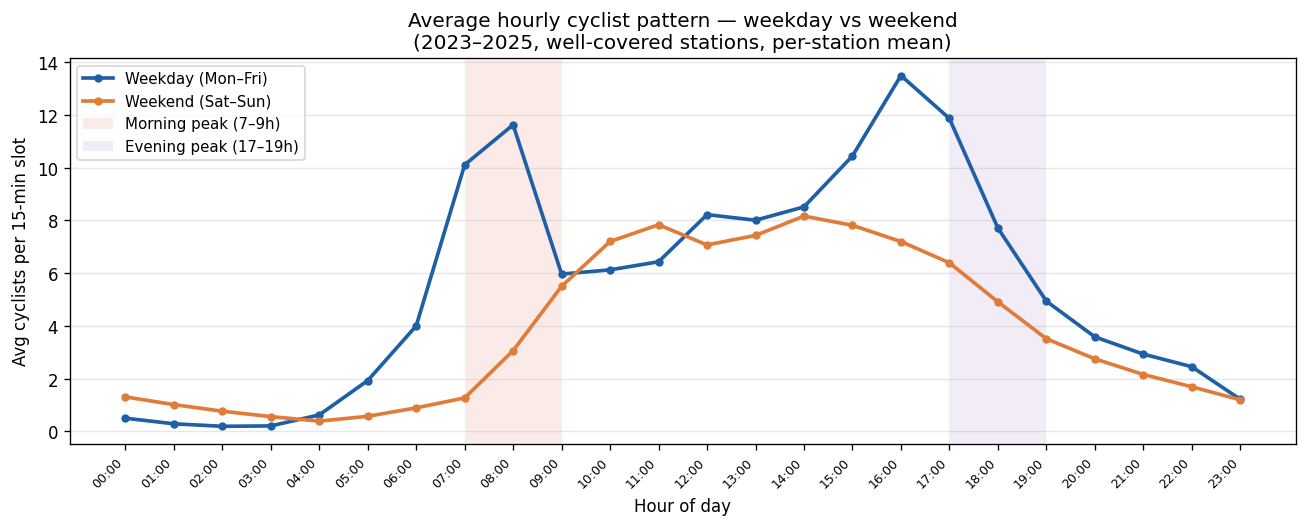

Weekday peak hour             : 16:00
Weekend peak hour             : 14:00
Weekday evening avg (17–18h)  : 9.78  (overall mean: 5.47)

  Check IN+OUT aggregation — possible direction handling issue.


In [14]:
# ── sanity check: average hourly cyclist pattern — weekday vs weekend ─────────
tmp = df_clean[["van", "aantal", "low_coverage"]].copy()
tmp["hour"]       = tmp["van"].dt.hour
tmp["dayofweek"]  = tmp["van"].dt.dayofweek
tmp["is_weekend"] = tmp["dayofweek"] >= 5

tmp_good = tmp[~tmp["low_coverage"] & tmp["aantal"].notna()]

hourly_avg = (
    tmp_good.groupby(["is_weekend", "hour"])["aantal"]
    .mean()
    .reset_index(name="avg_aantal")
)
weekday = hourly_avg[~hourly_avg["is_weekend"]].sort_values("hour")
weekend = hourly_avg[ hourly_avg["is_weekend"]].sort_values("hour")

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(weekday["hour"], weekday["avg_aantal"],
        color="#1f5fa6", lw=2.2, marker="o", ms=4, label="Weekday (Mon–Fri)")
ax.plot(weekend["hour"], weekend["avg_aantal"],
        color="#e07b39", lw=2.2, marker="o", ms=4, label="Weekend (Sat–Sun)")

ax.axvspan(7,  9,  color="#e25c46", alpha=0.12, lw=0, label="Morning peak (7–9h)")
ax.axvspan(17, 19, color="#9467bd", alpha=0.12, lw=0, label="Evening peak (17–19h)")

ax.set_xticks(range(24))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)],
                   rotation=45, ha="right", fontsize=7.5)
ax.set_xlabel("Hour of day")
ax.set_ylabel("Avg cyclists per 15-min slot")
ax.set_title(
    "Average hourly cyclist pattern — weekday vs weekend\n"
    "(2023–2025, well-covered stations, per-station mean)"
)
ax.legend(loc="upper left", fontsize=9)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIGS / "fig04_hourly_weekday_vs_weekend.png", dpi=150)
plt.show()

# ── verify peak visibility ─────────────────────────────────────────────────
wd_peak = int(weekday.loc[weekday["avg_aantal"].idxmax(), "hour"])
we_peak = int(weekend.loc[weekend["avg_aantal"].idxmax(), "hour"])
wd_eve  = weekday.loc[weekday["hour"].isin([17, 18]), "avg_aantal"].mean()
wd_mean = weekday["avg_aantal"].mean()

print(f"Weekday peak hour             : {wd_peak:02d}:00")
print(f"Weekend peak hour             : {we_peak:02d}:00")
print(f"Weekday evening avg (17–18h)  : {wd_eve:.2f}  (overall mean: {wd_mean:.2f})")

if (wd_peak in range(6, 10)) and (wd_eve > wd_mean):
    print("\nCommute peak pattern visible — IN+OUT aggregation is correct.")
else:
    print("\nWARNING: Expected weekday peaks at ~08:00 and ~17:00 not found.")
    print("  Check IN+OUT aggregation — possible direction handling issue.")

## 6. Save Cleaned Panel

In [15]:
# merge sites metadata before saving
SITES_COLS = ["site_id", "national_id", "lon", "lat", "naam",
              "eigenaar", "wegnr", "district", "gemeente",
              "interval_min", "install_date"]
SITE_KEEP  = ["site_id", "lon", "lat", "naam", "gemeente",
              "wegnr", "district", "install_date"]

sites = pd.read_csv(
    RAW_CYC / "sites.csv",
    header=None, names=SITES_COLS,
    dtype={"site_id": int, "national_id": "Int64",
           "lon": float, "lat": float, "interval_min": "Int16"},
    parse_dates=["install_date"],
)[SITE_KEEP]

df_clean = df_clean.merge(
    sites, left_on="site ID", right_on="site_id", how="left"
).drop(columns="site_id")

META_COLS = [c for c in SITE_KEEP[1:] if c in df_clean.columns]
FINAL_COLS = ["site ID", "van", "aantal", "low_coverage"] + META_COLS
df_clean = df_clean[FINAL_COLS]

out_path = PROCESSED / "panel_15min_clean.parquet"
df_clean.to_parquet(out_path, index=False)

size_mb = out_path.stat().st_size / 1_048_576
print("=" * 55)
print("panel_15min_clean.parquet — summary")
print("=" * 55)
print(f"  Shape                : {df_clean.shape}")
print(f"  Unique stations      : {df_clean['site ID'].nunique()}")
print(f"  Date range           : {df_clean['van'].min()} → {df_clean['van'].max()}")
print(f"  Low-coverage stations: {len(low_cov_ids)}")
print(f"  Total NaN (aantal)   : {df_clean['aantal'].isna().sum():,}")
print(f"  File size            : {size_mb:.1f} MB")
print(f"  Columns              : {df_clean.columns.tolist()}")
display(df_clean.head(4))

panel_15min_clean.parquet — summary
  Shape                : (15782400, 11)
  Unique stations      : 150
  Date range           : 2023-01-01 00:00:00 → 2025-12-31 23:45:00
  Low-coverage stations: 17
  Total NaN (aantal)   : 1,406,832
  File size            : 52.8 MB
  Columns              : ['site ID', 'van', 'aantal', 'low_coverage', 'lon', 'lat', 'naam', 'gemeente', 'wegnr', 'district', 'install_date']


,site ID,van,aantal,low_coverage,lon,lat,naam,gemeente,wegnr,district,install_date
0,1,2023-01-01 00:00:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
1,1,2023-01-01 00:15:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
2,1,2023-01-01 00:30:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
3,1,2023-01-01 00:45:00,0.0,False,4.456122,50.916183,Machelen,Machelen,T2110002,AWV212,2019-08-22
